In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 80
T2 = 80

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qubit")

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

x_gate = qt.Qobj([[0, 1],[1, 0]])

C:\Users\girgi\AppData\Local\Temp\ipykernel_3016\2557974889.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_3016\2557974889.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_3016\2557974889.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [4]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [5]:
# build circuit 
# delay gate for ideal setup 
states = []
fids = []
# new_fid = []
duration_delay = .2
delay_state = trotter.apply(rho_encoded, duration= duration_delay, unitary=[cnot3, cnot5])
for i in range(len(delay_state)):
    a = qt.ptrace(delay_state[i], [0,1,2])
    states.append(delay_state[i])
    # fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, a))
    # new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=a))
delay_state = trotter.apply(rho=delay_state[-1], duration=duration_delay, unitary=[cnot4, cnot6])
for i in range(len(delay_state)):
    a = qt.ptrace(delay_state[i], [0,1,2])
    states.append(delay_state[i])

# run the parity checkers
# cnot_3 = cnot5 * states[-1] * cnot5.dag()
# cnot_4 = cnot6 * cnot_3 * cnot6.dag()
# cnot_5 = cnot3 * cnot_4 * cnot3.dag()
# cnot_6 = cnot4 * cnot_5 * cnot4.dag()
# states.append(cnot_6)
# fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, qt.ptrace(states[-1], [0,1,2])))
# new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=qt.ptrace(states[-1], [0,1,2])))


In [6]:
qt.ptrace(states[-1], [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.95682748e-07 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 9.95548076e-07 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 9.97502794e-04
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  9.95468032e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.97502746e-04 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 9.97502725e-04 0.00000000e+00]
 [0.00000000e+00 0.0000

In [7]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .001
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=[recovery_ops[i]])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    # fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

total_time = 4 * .05 + duration_recovery

[0.9973783534144012, 0.001185967969673656, 0.0011834722293261155, 0.00025220638659910846]


In [8]:
qt.ptrace(states[-1], [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[5.11954157e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 4.97464417e-04 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.25339161e-07 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.18645765e-03
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  6.80161358e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 2.52755354e-04 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 6.87178659e-04 0.00000000e+00]
 [0.00000000e+00 0.0000

[5.119541568196772e-07, 0.0004974644171210978, 6.253391613276334e-07, 0.0011864576532085406, 6.801613578697581e-07, 0.00025275535435369397, 0.0006871786590163018, 0.9973743264616244]


Text(0.5, 0, 'time (dt)')

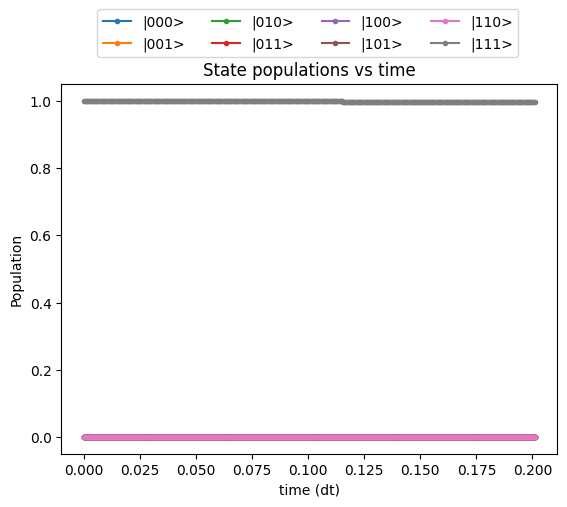

In [9]:
time = np.linspace(0, total_time, len(states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(states)):
        data.append(np.real(qt.ptrace(states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")

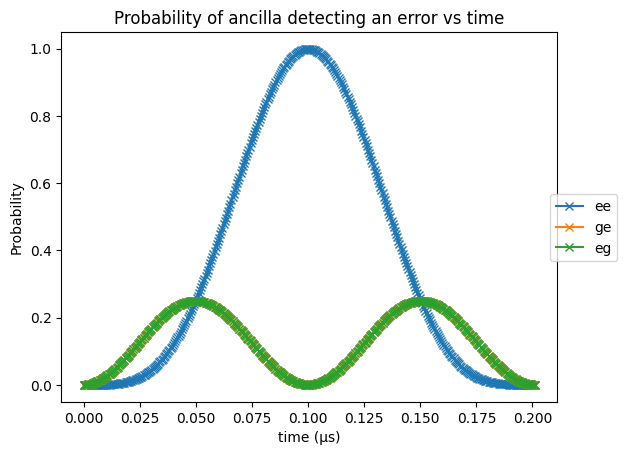

In [10]:
# plotting the ancilla populations 
# getting the probability that the ancillas measure a syndrome 
# states is the function that holds the states as a function o
prob_gg = []
prob_ge = []
prob_eg = []
prob_ee = []

state_gg = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)).dag()
state_ge = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)).dag()
state_eg = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)).dag()
state_ee = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)).dag()
for i in states:
    reduced_state = qt.ptrace(i, [3, 4])
    prob_gg.append((state_gg * reduced_state).tr())
    prob_ge.append((state_ge * reduced_state).tr())
    prob_eg.append((state_eg * reduced_state).tr())
    prob_ee.append((state_ee * reduced_state).tr())

probs = [prob_gg, prob_ge, prob_eg, prob_ee]

fig, ax = plt.subplots()
# for i in probs:
#     ax.plot(time, i)
# ax.plot(time, prob_ge)
# ax.plot(time, prob_eg)
ax.plot(time, prob_ee, marker = "x", label = "ee")
ax.plot(time, prob_ge, marker = "x", label = "ge")
ax.plot(time, prob_eg, marker = "x", label = "eg")
    
# seems reasonable 
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Probability")
ax.set_title("Probability of ancilla detecting an error vs time")
fig.legend(loc = "center right")

In [11]:
# the only way that these can be compared to each other is by running all of these a few times because one stabilizer round is not enough for data collection


In [12]:
# this is much better than not parallelizing them 